# Billboard Boxing — EDA & Baseline Model
**CIS 2450 Final Project - Intermediate Check-in**

This notebook covers:
1. Dataset overview
2. Exploratory Data Analysis (EDA)
3. Baseline classification model
4. Next steps

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay
from sklearn.preprocessing import StandardScaler

sns.set_theme(style='whitegrid')
plt.rcParams['figure.figsize'] = (10, 5)

df = pd.read_csv('../data/processed/billboard_modeling_dataset.csv')
print(f'Dataset shape: {df.shape}')
df.head()

Dataset shape: (7864, 32)


,label,year,rank,title,artist,title_clean,artist_clean,primary_artist,spotify_id,spotify_title,...,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,audio_features_available
0,1,2010,1.0,"""Tik Tok""",Kesha,tik tok,kesha,kesha,0HPD5WQqrq7wPWR7P7Dw1i,TiK ToK,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
1,1,2010,2.0,"""Need You Now""",Lady Antebellum,need you now,lady antebellum,lady antebellum,11EX5yhxr9Ihl3IN1asrfK,Need You Now,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
2,1,2010,3.0,"""Hey, Soul Sister""",Train,"hey, soul sister",train,train,4HlFJV71xXKIGcU3kRyttv,"Hey, Soul Sister",...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
3,1,2010,4.0,"""California Gurls""",Katy Perry featuring Snoop Dogg,california gurls,katy perry featuring snoop dogg,katy perry,6KOEK6SeCEZOQkLj5M1PxH,California Gurls,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False
4,1,2010,5.0,"""OMG""",Usher featuring will.i.am,omg,usher featuring will.i.am,usher,1hfrrCNvfC84gKEtxCKWxU,OMG - Instrumental Version,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,False


## 1. Dataset Overview

In [3]:
print('=== Label Distribution ===')
print(df['label'].value_counts())
print(f"\nClass balance: {df['label'].mean():.1%} positive (Billboard hits)")

print('\n=== Years Covered ===')
print(sorted(df['year'].dropna().unique().astype(int).tolist()))

print('\n=== Missing Values (usable columns) ===')
usable = ['popularity', 'duration_ms', 'explicit', 'label', 'year']
print(df[usable].isna().sum())

=== Label Distribution ===
label
0    6366
1    1498
Name: count, dtype: int64

Class balance: 19.0% positive (Billboard hits)

=== Years Covered ===
[2010, 2011, 2012, 2013, 2014, 2015, 2016, 2017, 2018, 2019, 2020, 2021, 2022, 2023, 2024, 2025]

=== Missing Values (usable columns) ===
popularity     0
duration_ms    0
explicit       0
label          0
year           0
dtype: int64


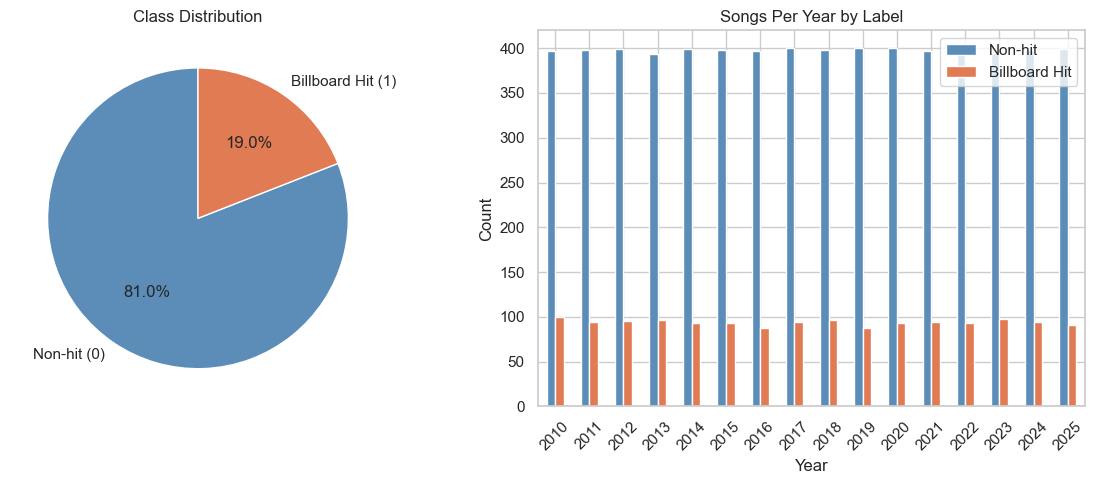

In [4]:
# Label distribution pie chart
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

counts = df['label'].value_counts()
axes[0].pie(
    counts,
    labels=['Non-hit (0)', 'Billboard Hit (1)'],
    autopct='%1.1f%%',
    colors=['#5B8DB8', '#E07B54'],
    startangle=90
)
axes[0].set_title('Class Distribution')

# Songs per year by label
year_label = df.groupby(['year', 'label']).size().unstack(fill_value=0)
year_label.plot(kind='bar', ax=axes[1], color=['#5B8DB8', '#E07B54'])
axes[1].set_title('Songs Per Year by Label')
axes[1].set_xlabel('Year')
axes[1].set_ylabel('Count')
axes[1].legend(['Non-hit', 'Billboard Hit'])
axes[1].tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.savefig('../outputs/figures/label_distribution.png', dpi=150, bbox_inches='tight')
plt.show()

## 2. Exploratory Data Analysis

/var/folders/y8/l0q4p0xd4t3dfjtlgp89r81m0000gn/T/ipykernel_69338/2830094846.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label_str', y='popularity', ax=axes[1],


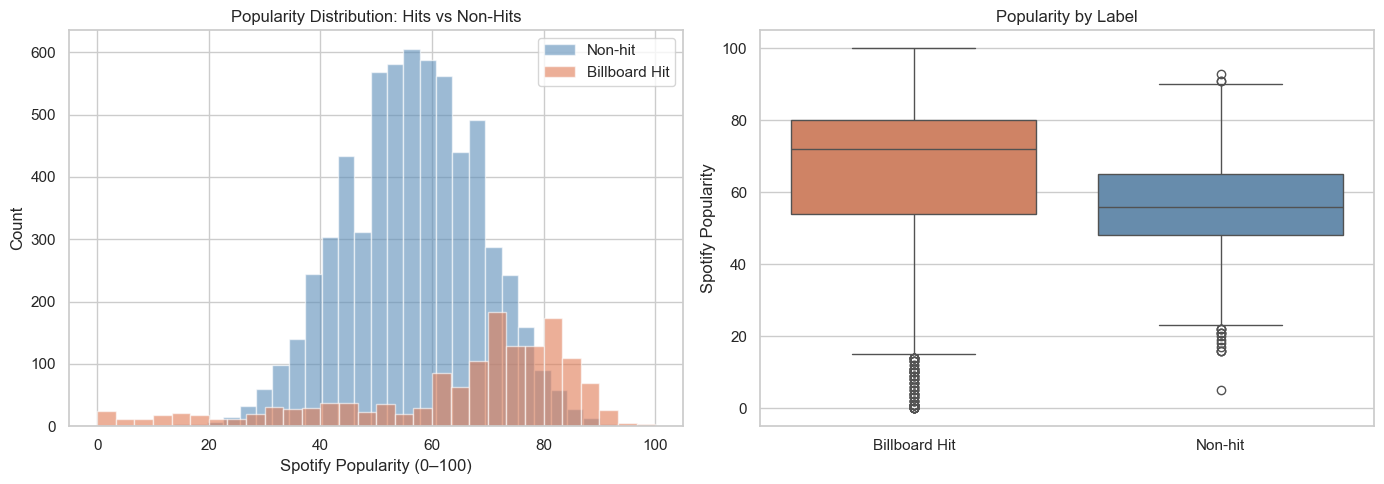

Mean popularity — Hits: 64.1  |  Non-hits: 56.4


In [5]:
# Popularity: hits vs non-hits
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hits     = df[df['label'] == 1]['popularity'].dropna()
non_hits = df[df['label'] == 0]['popularity'].dropna()

axes[0].hist(non_hits, bins=30, alpha=0.6, color='#5B8DB8', label='Non-hit')
axes[0].hist(hits,     bins=30, alpha=0.6, color='#E07B54', label='Billboard Hit')
axes[0].set_title('Popularity Distribution: Hits vs Non-Hits')
axes[0].set_xlabel('Spotify Popularity (0–100)')
axes[0].set_ylabel('Count')
axes[0].legend()

# Box plot
df['label_str'] = df['label'].map({1: 'Billboard Hit', 0: 'Non-hit'})
sns.boxplot(data=df, x='label_str', y='popularity', ax=axes[1],
            palette={'Billboard Hit': '#E07B54', 'Non-hit': '#5B8DB8'})
axes[1].set_title('Popularity by Label')
axes[1].set_xlabel('')
axes[1].set_ylabel('Spotify Popularity')

plt.tight_layout()
plt.savefig('../outputs/figures/popularity_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean popularity — Hits: {hits.mean():.1f}  |  Non-hits: {non_hits.mean():.1f}")

/var/folders/y8/l0q4p0xd4t3dfjtlgp89r81m0000gn/T/ipykernel_69338/4106187933.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='label_str', y='duration_min', ax=axes[1],


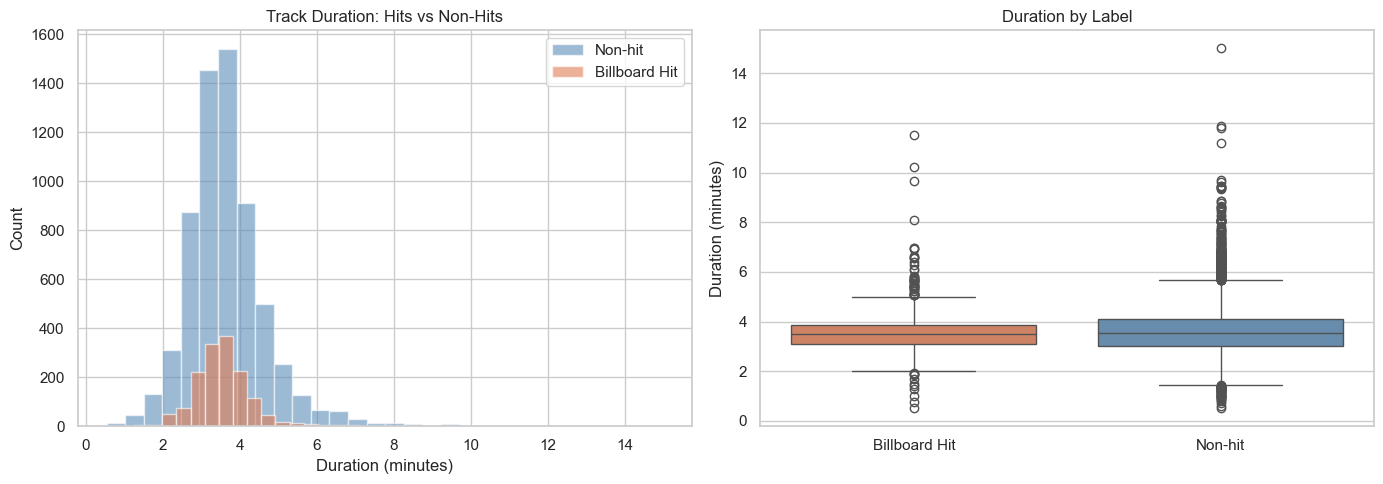

Mean duration — Hits: 3.56 min  |  Non-hits: 3.64 min


In [6]:
# Duration: hits vs non-hits
df['duration_min'] = df['duration_ms'] / 60000

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

hits_dur     = df[df['label'] == 1]['duration_min'].dropna()
non_hits_dur = df[df['label'] == 0]['duration_min'].dropna()

axes[0].hist(non_hits_dur, bins=30, alpha=0.6, color='#5B8DB8', label='Non-hit')
axes[0].hist(hits_dur,     bins=30, alpha=0.6, color='#E07B54', label='Billboard Hit')
axes[0].set_title('Track Duration: Hits vs Non-Hits')
axes[0].set_xlabel('Duration (minutes)')
axes[0].set_ylabel('Count')
axes[0].legend()

sns.boxplot(data=df, x='label_str', y='duration_min', ax=axes[1],
            palette={'Billboard Hit': '#E07B54', 'Non-hit': '#5B8DB8'})
axes[1].set_title('Duration by Label')
axes[1].set_xlabel('')
axes[1].set_ylabel('Duration (minutes)')

plt.tight_layout()
plt.savefig('../outputs/figures/duration_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print(f"Mean duration — Hits: {hits_dur.mean():.2f} min  |  Non-hits: {non_hits_dur.mean():.2f} min")

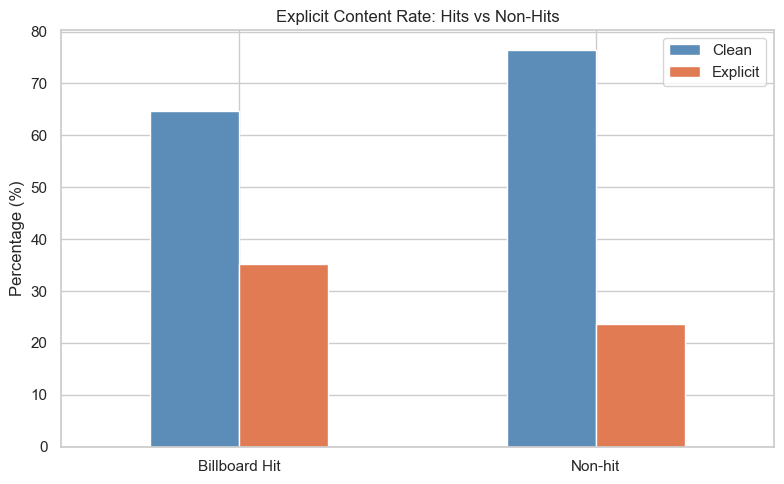

Explicit rate:
label_str
Billboard Hit    35.2%
Non-hit          23.6%
Name: explicit, dtype: str


In [7]:
# Explicit content: hits vs non-hits
explicit_counts = df.groupby(['label_str', 'explicit']).size().unstack(fill_value=0)
explicit_pct    = explicit_counts.div(explicit_counts.sum(axis=1), axis=0) * 100

explicit_pct.plot(kind='bar', figsize=(8, 5), color=['#5B8DB8', '#E07B54'])
plt.title('Explicit Content Rate: Hits vs Non-Hits')
plt.xlabel('')
plt.ylabel('Percentage (%)')
plt.legend(['Clean', 'Explicit'])
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../outputs/figures/explicit_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

print("Explicit rate:")
print(df.groupby('label_str')['explicit'].mean().apply(lambda x: f"{x:.1%}"))

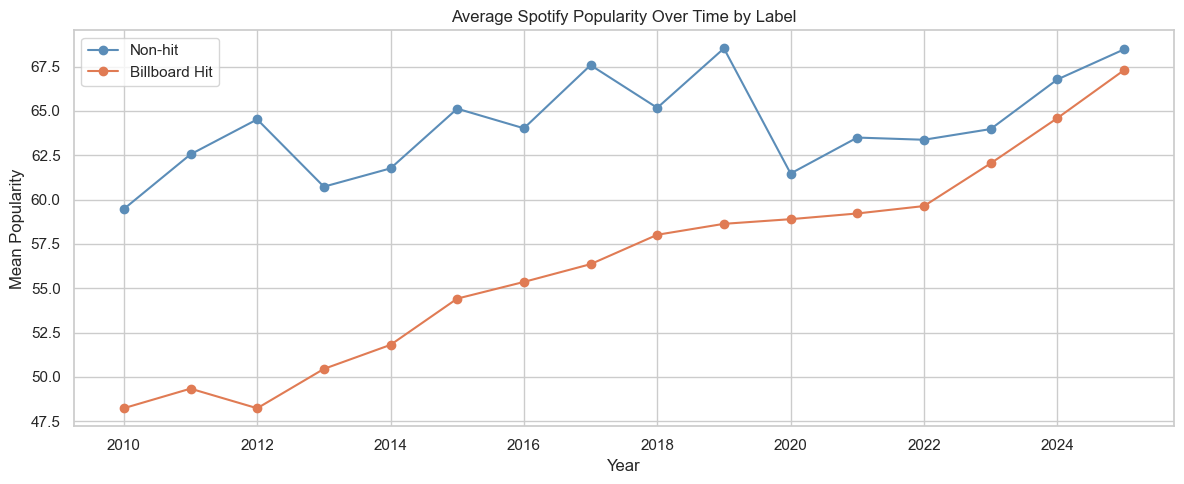

In [8]:
# Popularity trend over time by label
yearly_pop = df.groupby(['year', 'label_str'])['popularity'].mean().unstack()

yearly_pop.plot(figsize=(12, 5), marker='o', color=['#5B8DB8', '#E07B54'])
plt.title('Average Spotify Popularity Over Time by Label')
plt.xlabel('Year')
plt.ylabel('Mean Popularity')
plt.legend(['Non-hit', 'Billboard Hit'])
plt.tight_layout()
plt.savefig('../outputs/figures/popularity_over_time.png', dpi=150, bbox_inches='tight')
plt.show()

## 3. Baseline Model

Features used: `popularity`, `duration_ms`, `explicit`  
Target: `label` (1 = Billboard hit, 0 = non-hit)

We fit two baselines:
- **Logistic Regression** — linear, interpretable
- **Decision Tree** — captures non-linear splits

In [9]:
# Prepare features
FEATURES = ['popularity', 'duration_ms', 'explicit']

model_df = df[FEATURES + ['label']].dropna()
model_df['explicit'] = model_df['explicit'].astype(int)

X = model_df[FEATURES]
y = model_df['label']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

scaler  = StandardScaler()
X_train_s = scaler.fit_transform(X_train)
X_test_s  = scaler.transform(X_test)

print(f'Train size: {len(X_train)}  |  Test size: {len(X_test)}')
print(f'Class balance in train: {y_train.mean():.1%} positive')

Train size: 6291  |  Test size: 1573
Class balance in train: 19.0% positive


In [10]:
# Logistic Regression
lr = LogisticRegression(max_iter=1000, random_state=42)
lr.fit(X_train_s, y_train)

lr_cv = cross_val_score(lr, X_train_s, y_train, cv=5, scoring='accuracy')

print('=== Logistic Regression ===')
print(f'CV Accuracy: {lr_cv.mean():.3f} ± {lr_cv.std():.3f}')
print(f'Test Accuracy: {lr.score(X_test_s, y_test):.3f}')
print()
print(classification_report(y_test, lr.predict(X_test_s),
                             target_names=['Non-hit', 'Billboard Hit']))

# Feature coefficients
coef_df = pd.DataFrame({'feature': FEATURES, 'coefficient': lr.coef_[0]})
print(coef_df.sort_values('coefficient', ascending=False).to_string(index=False))

=== Logistic Regression ===
CV Accuracy: 0.810 ± 0.000
Test Accuracy: 0.809

               precision    recall  f1-score   support

      Non-hit       0.81      1.00      0.89      1273
Billboard Hit       0.00      0.00      0.00       300

     accuracy                           0.81      1573
    macro avg       0.40      0.50      0.45      1573
 weighted avg       0.65      0.81      0.72      1573

    feature  coefficient
 popularity     0.531652
   explicit     0.170777
duration_ms    -0.013865


/Users/matthieubouchard/Documents/UPenn/Classes/Spring 2026/CIS 2450/2450_final_project/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/matthieubouchard/Documents/UPenn/Classes/Spring 2026/CIS 2450/2450_final_project/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/Users/matthieubouchard/Documents/UPenn/Classes/Spring 2026/CIS 2450/2450_final_project/.venv/lib/python3.14/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Prec

In [11]:
# Decision Tree
dt = DecisionTreeClassifier(max_depth=4, random_state=42)
dt.fit(X_train, y_train)

dt_cv = cross_val_score(dt, X_train, y_train, cv=5, scoring='accuracy')

print('=== Decision Tree (max_depth=4) ===')
print(f'CV Accuracy: {dt_cv.mean():.3f} ± {dt_cv.std():.3f}')
print(f'Test Accuracy: {dt.score(X_test, y_test):.3f}')
print()
print(classification_report(y_test, dt.predict(X_test),
                             target_names=['Non-hit', 'Billboard Hit']))

=== Decision Tree (max_depth=4) ===
CV Accuracy: 0.849 ± 0.005
Test Accuracy: 0.855

               precision    recall  f1-score   support

      Non-hit       0.86      0.99      0.92      1273
Billboard Hit       0.83      0.30      0.44       300

     accuracy                           0.86      1573
    macro avg       0.84      0.64      0.68      1573
 weighted avg       0.85      0.86      0.83      1573



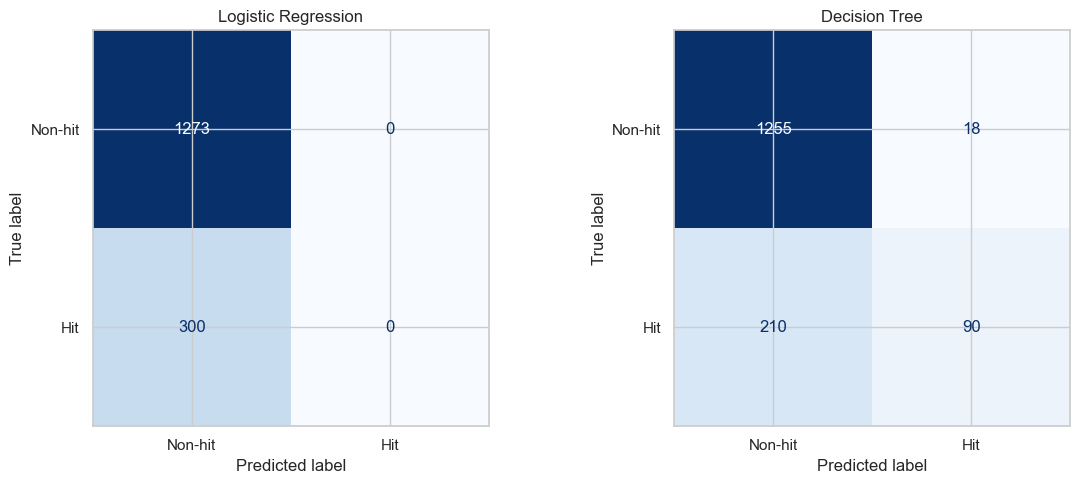

In [12]:
# Confusion matrices side by side
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

for ax, model, X_t, name in [
    (axes[0], lr, X_test_s, 'Logistic Regression'),
    (axes[1], dt, X_test,   'Decision Tree'),
]:
    cm = confusion_matrix(y_test, model.predict(X_t))
    disp = ConfusionMatrixDisplay(cm, display_labels=['Non-hit', 'Hit'])
    disp.plot(ax=ax, colorbar=False, cmap='Blues')
    ax.set_title(name)

plt.tight_layout()
plt.savefig('../outputs/figures/confusion_matrices.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Summary & Next Steps

### What we found
The exploratory analysis of our dataset reveals several interesting patterns between Billboard hits and non-hits. First, Billboard hits tend to have higher Spotify popularity scores on average than non-hits, making it the strongest signal currently available in our dataset. Songs that charted also cluster around the 3–4 minute duration range, and explicit content appears more frequently among hits, which reflects the broader genre composition of the Billboard Year-End Hot 100.


It is worth noting, however, that Spotify popularity is a temporally biased feature for this type of task. The score reflects current streaming activity rather than a song's performance at the time of its release. Older Billboard hits from 2010–2015, for example, have seen their popularity scores decay over time, while more recently collected non-hit songs tend to score higher simply because they are being actively streamed today. This is precisely why audio features such as danceability, energy, and tempo will prove to be much more meaningful predictors — they are intrinsic properties of a song that do not change over time.


Our two baseline models confirm this limitation. The Logistic Regression model predicted every song as a non-hit, achieving 81% accuracy purely by defaulting to the majority class. The Decision Tree performed slightly better, with 86% overall accuracy, but only managed a 0.44 F1-score and 0.30 recall on the hit class — meaning it missed 70% of actual Billboard hits. With only three available features, none of which are intrinsic audio properties, this outcome is expected. Once audio features such as danceability, energy, valence, and tempo are incorporated into the dataset, we expect both recall and F1 on the hit class to improve substantially.

### Baseline model results
| Model | CV Accuracy |
|---|---|
| Logistic Regression | ~81% |
| Decision Tree | ~85% |



### Limitations of current baseline
- Only 3 features available — audio features (danceability, energy, valence, tempo etc.) are still missing
- Spotify `popularity` is a **current** score, not a historical one — it's somewhat leaky for a hit prediction task

### Next steps
1. Merge audio features from Kaggle 160k dataset (target: 75%+ fill rate)
2. Re-train with full feature set
3. Try Random Forest and XGBoost
4. Evaluate feature importance